### Display records of a patient 

UID: 1
Problems: normal
Findings: The cardiac silhouette and mediastinum size are within normal limits. There is no pulmonary edema. There is no focal consolidation. There are no XXXX of a pleural effusion. There is no evidence of pneumothorax.


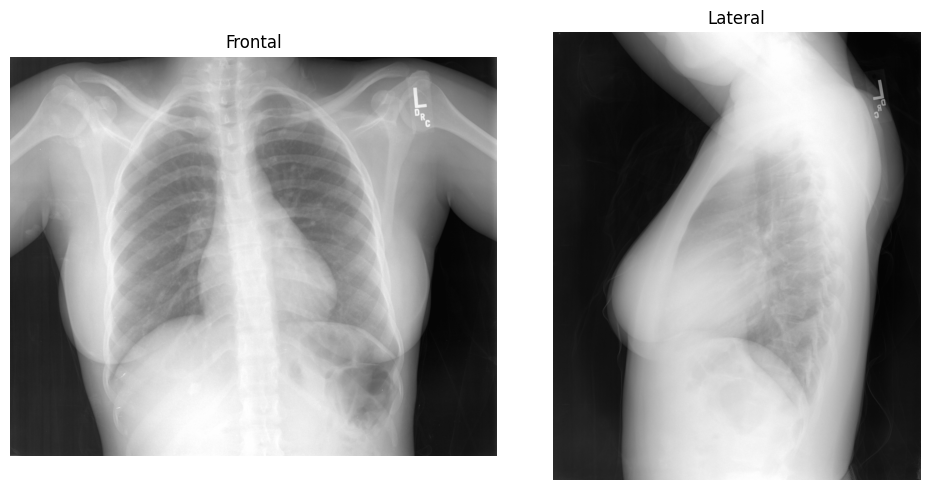

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import os

# Load files
reports = pd.read_csv("indiana_reports.csv")
projections = pd.read_csv("indiana_projections.csv")

# Select one patient
uid = 1

# Get patient report info
row = reports[reports['uid'] == uid]
if row.empty:
    print("No report found for UID:", uid)
else:
    row = row.iloc[0]
    print("UID:", uid)
    print("Problems:", row.get('Problems', 'N/A'))
    print("Findings:", row.get('findings', 'N/A'))

# Get images for that patient
patient_images = projections[projections['uid'] == uid]

if patient_images.empty:
    print("No images found for UID:", uid)
else:
    image_folder = "images\images_normalized"  # remove trailing slash
    images = []
    titles = []

    for _, r in patient_images.iterrows():
        img_path = os.path.join(image_folder, r['filename'])
        if os.path.exists(img_path):
            try:
                img = Image.open(img_path).convert('RGB')
                images.append(img)
                titles.append(r.get('projection', ''))
            except Exception as e:
                print(f"Failed to open {img_path}: {e}")
        else:
            print("Not found:", img_path)

    if images:
        plt.figure(figsize=(10, 5))
        for i, img in enumerate(images):
            plt.subplot(1, len(images), i+1)
            plt.imshow(img)
            plt.title(titles[i])
            plt.axis('off')
        plt.tight_layout()
        plt.show()
    else:
        print("No valid images to display.")

In [7]:
import pandas as pd

# Load dataset
df = reports

# Initialize a set to store unique problems
unique_problems = set()

# Iterate through the Problems column
for entry in df["Problems"].dropna():
    # Split by semicolon
    problems = entry.split(";")
    
    # Strip spaces and add to set
    for p in problems:
        unique_problems.add(p.strip())

# Count unique problems
print("Number of unique problem labels:", len(unique_problems))

# (Optional) print them
print("\nUnique Problems:")
print(unique_problems)

Number of unique problem labels: 121

Unique Problems:
{'Lung Diseases, Interstitial', 'Consolidation', 'Aortic Aneurysm', 'Hypovolemia', 'Cavitation', 'Hypertension, Pulmonary', 'Ribs', 'Scoliosis', 'Diaphragm', 'Expansile Bone Lesions', 'Shoulder', 'Subcutaneous  Emphysema', 'Trachea, Carina', 'Tuberculosis', 'Spinal Fusion', 'Lumbar Vertebrae', 'Cardiomegaly', 'Sulcus', 'Lymph Nodes', 'Subcutaneous Emphysema', 'Bone Diseases, Metabolic', 'Blood Vessels', 'Pulmonary Congestion', 'Bullous Emphysema', 'Mass', 'Mastectomy', 'Hemothorax', 'Foreign Bodies', 'Pneumoperitoneum', 'Pulmonary Edema', 'Dislocations', 'Arthritis', 'Shift', 'Opacity', 'Contrast Media', 'Pectus Carinatum', 'Humerus', 'Sarcoidosis', 'Nipple Shadow', 'Cysts', 'Trachea', 'Cervical Vertebrae', 'Osteophyte', 'Implanted Medical Device', 'Hyperostosis, Diffuse Idiopathic Skeletal', 'Bronchiectasis', 'Bone and Bones', 'Infiltrate', 'normal', 'Heart Failure', 'Lucency', 'Mediastinum', 'Epicardial Fat', 'Bronchitis', 'Cathe

In [8]:
# Count empty cells (NaN or blank strings)
empty_count = df["findings"].isna().sum() + (df["findings"].str.strip() == "").sum()

print("Number of empty cells in 'findings' column:", empty_count)

Number of empty cells in 'findings' column: 514


In [9]:
print("Total number of records:", df.shape[0])

Total number of records: 3851


In [10]:
print("No of patient records that can be considered to our system implementation: ",df.shape[0]-empty_count)

No of patient records that can be considered to our system implementation:  3337
